In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST, MNIST
from torchvision import transforms
import seaborn as sns

# Neural Networks with PyTorch

In the previous example, we saw a naked neural network created from scratch. This model works, but it is not very efficient or flexible. In practice, we create our models using a deep learning framework like PyTorch or TensorFlow. These libraries are roughly the equivalent of Scikit-Learn, but for neural networks. Importantly for us, pytorch will handle a lot of the lower level details and math, allowing us to focus on building and training our models.

## PyTorch Setup

We can start by importing the libraries and checking for GPU availability. When doing deep learning, it is important to use a GPU if one is available, as training on a CPU can be very slow. The code below checks if a GPU is available and sets the device accordingly. The priority here is:

1. Use CUDA, which is for nVIDIA GPUs. 
2. Use MPS, which is for Apple Silicon GPUs.
3. Use the CPU if neither of the above are available.

If you happen to have some other type of GPU, such as AMD, you may need to modify this to use it. In these workbooks, we'll generally assume that we'll be using CUDA. If in colab, I beleive any of the GPU options all use CUDA. 

### Using Devices

Below, when we do the model training, we will need to make sure that the data and the model are on the same device. So, assuming we are training on the GPU, the model and the dataloaders need to be 'sent' to the GPU before we can use them. This is done with the .to() method, which we will see in the training loop. If we try to use the model and the data on different devices, we will get an error and our code will fail. On the other side, you might get errors if you try to use those objects to do something on the CPU like plotting, if so, we can use .to('cpu') to send them back to the CPU for normal computing use. In larger, 'real', scenarios, manipulating where different calculations are done is part of making the training process more efficient, by aiming to keep the GPU as busy as possible. 

<b>Note:</b> this little if statement allows the same code to run on different hardware without needing to change anything. If we are doing a larger project, we might also include some lines in here to change things like epochs, saving/loading from disk, batch size, or other stuff that might be different based on the hardware we are using. The speed differences are massive, so if you're just testing something out on the CPU, you may want to use fewer epochs or smaller batch sizes to allow things to work in a reasonable time frame.

In [20]:
#check for gpu and use if available

# prefer CUDA, then MPS, otherwise CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## Load Data

In neural networks, we typically don't handle data in the same way as we do in traditional machine learning. Neural network datasets tend to be large, more complex, and frequently require pre-processing. In addition, we are often using with data that is simply too large for us to fit it into memory, or GPU memory, all at one time. 

To deal with these issues efficiently, PyTorch provides a set of tools for loading and managing data. The two main components are the Dataset and DataLoader classes. The Dataset class is responsible for loading and pre-processing the data, while the DataLoader class is responsible for batching and shuffling the data during training. We don't manipulate data row-by-row like we did with dataframes, instead we aim our data objects at our data and rely on them to provide data to the algorithm as needed.

### Dataset

The dataset is a PyTorch class that provides an interface for loading and pre-processing data. In many/most neural network scenarios we will have data that is too large to fit into memory, as we would do with a dataframe. The dataset class bridges this gap by managing the loading of data from the disk and providing it to the model as it is needed. We can use a dataset object as "the data" and it'll manage what is in memory and what is not.

The transform parameter is used to specify any pre-processing steps that we want to apply to the data. This can include things like normalization, data augmentation, or any other transformations that we want to apply to the data before it is fed into the model. The dataset will apply these transformations on-the-fly as it loads the data. Managing when and where data is processed is one of the things that we can manage to make training efficient. For example, we can choose to do data augmentation on the CPU while the GPU is training the model, which can help to keep the GPU fully utilized and speed up training.

### DataLoader

The dataloader uses the dataset, and manages the "model and training specific" details of loading data. The primary things that the dataloader manages are:

1. Batching: The dataloader can have batch sizes set. This is important in ensuring that each batch can fit in GPU memory (a similar concern to the dataset, but at a different level) as well as controling the stochasticity of the training process. As with any gradient descent based algorithm, the parameters are updated after each batch, so the batch size setting will impact the speed, convergance, and performance of the model.
2. Shuffling: The dataloader can shuffle the data at the start of each epoch. We almost always want to shuffle the training data, as this can help generalization and prevent the model from "getting stuck" in a local minima. We typically do not shuffle the validation or test data. 

#### Sample Data

We'll use some images for sample data, as images tend to be even a little easier to deal with than basic tablular data. 

<b>Note:</b> when using most of the datasets that we load via code, the actual data is downloaded and cached on the disk in the root location. If using colab, this data needs to be downloaded with each new session. 

In [21]:
BATCH_SIZE = 128

fashion_mnist_train = FashionMNIST(root="data",
                                  train=True,
                                  download=True,
                                  transform=transforms.ToTensor())
fashion_mnist_test = FashionMNIST(root="data",
                                 train=False,
                                 download=True,
                                 transform=transforms.ToTensor())
train_loader = DataLoader(fashion_mnist_train, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(fashion_mnist_test, batch_size=BATCH_SIZE, shuffle=False)
# This I copied from the internet, I didn't extract it. 
label_mapping = {0: "T-shirt/top",
                 1: "Trouser",
                 2: "Pullover",
                 3: "Dress",
                 4: "Coat",
                 5: "Sandal",
                 6: "Shirt",
                 7: "Sneaker",
                 8: "Bag",
                 9: "Ankle boot"}

### Using DataLoaders

Once we have our dataloaders set up, they will do all the data stuff for training models automatically, but they aren't as user friendly to look at as something like a dataframe. Remember, we can't physically load all the data into memory, so doing things like .head() or .sample() isn't really an option. To get the data, we need to extract a batch from the dataloader, which will provide us with a tuple of data items and their labels. 

### Preview Data

To preview the data, we must extract a batch from the DataLoader. A batch is simply a subset of the data that will be processed together. Batching is important for efficiency, as it allows us to take advantage of parallel processing on the GPU. The code below extracts a single batch from the DataLoader and displays a few sample images along with their labels.

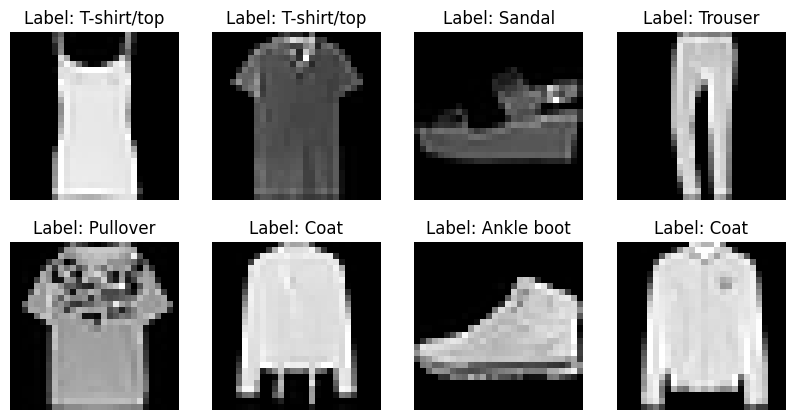

In [22]:
def imagePreview(images, labels, label_mapping=label_mapping):


    fig = plt.figure(figsize=(10, 5))
    for i in range(8):
        ax = fig.add_subplot(2, 4, i+1)
        img = images[i].numpy().squeeze()
        ax.imshow(img, cmap='gray')
        if label_mapping is not None:
            ax.set_title(f"Label: {label_mapping[labels[i].item()]}")
        else:
            ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.show()

# Get a batch of training data
sample_images = iter(train_loader)
images, labels = next(sample_images)

imagePreview(images, labels, label_mapping)

#### Dataset Information

This little function gives a look at a batch of data. Every time the loader produces some data, this is the shape:
<ul>
<li> The first dimension is the batch size, which is the number of samples in the batch. </li>
<li> The second dimension is the number of channels in the image. For grayscale images, this is 1, and for RGB images, this is 3. </li>
<li> The third and fourth dimensions are the height and width of the image, respectively. </li>
</ul>

When using the data, these dimensions are important because the model's structure and the data size need to match. 

In [23]:
def batchInfo(dataloader):
    sample_batch = next(iter(dataloader))
    images, labels = sample_batch
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Data type of images: {images.dtype}")

batchInfo(train_loader)

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])
Data type of images: torch.float32


## Model Creation

We have datasets and dataloaders ready to manage and provide the data, we can now create a model. In PyTorch, we typically create a model by subclassing the nn.Module class. This allows us to define the architecture of the model and the forward pass in a clear and organized way. 

### Dense/Feedforward Networks

Dense networks, also known as feedforward networks, are the most basic type of neural network. They consist of layers of neurons where each neuron is connected to every neuron in the previous layer. They are effectively a seried of logistic regression models stacked on top of each other. Dense networks are the *default* type of model and a good starting point for a baseline. 

Later, we'll also see dense networks combined with other types of layers, such as convolutional layers, that are better able to process specific types of data, such as images.

### Model Structure

Our model can have almost any structure we want, as long as we meet the requirements of our data. The basic constraints we need to meet are:
<ul>
<li>The input layer must have the same number of neurons as the number of features in the data.</li>
<li>The output layer must have the same number of neurons as the number of classes in the data (or one if a regression problem).</li>
</ul>

Between these two layers, we have hidden layers, which are where the magic happens for neural networks. The hidden layers are what allows the model to be very flexible and able to capture complex relationships in data that *standard* models are unable to. The hidden layers can have any number of neurons and can be arranged in any way we want. The more and larger layers we have, the higher the capacity of the model is, or the ability of the model to fit itself to the data. However, higher capacity also means a higher risk of overfitting, so we need to be careful when designing our model architecture. In this sense, neural networks are a lot like trees - the larger it is, the more of an overfit we get. 

### Universal Approximation Theorem

Neural networks are often referred to as "universal function approximators". This means that, given enough (which can vary infiniately) capacity and at least one hidden layer, a neural network can approximate any function to an arbitrary degree of accuracy. In other words, our models (of almost any design) can theoretically learn to fit any data and make any prediction. In reality, we proably don't have enough data and/or time to get a *bad* model to perform as well as a good fitting model, we just won't converge on the good solution in time. 

This is reflected in practice in the odd experiences we may have with tuning neural networks, where changes to the architecture or hyperparameters will impact performance, but not necissarily in a predictable way. We can have models of different sizes that perform similarly, and models of a similar size that perform very differently (with different shapes and/or hyperparameters). This is one of the reasons why tuning neural networks can be so difficult, and why we often rely on heuristics and trial-and-error to find good architectures and hyperparameters. Any model could be great, but we generally can't train any model to perform well on any given scenario, we're limited by our data and time. We need to start with something that is likely to perform well, from that point, many variations of model structure can train themselves to perform well. 

### The NN Module and Models

When creating a model in PyTorch, our subclass of the nn.Module class is our model. We inherit the vast majority of the functionality from the parent class, we really only need to provide the unique parts for our model:

1. The __init__ method, where we define the layers of the model. This is where we specify the architecture of the model, such as how many layers and how many neurons in each layer. Each layer is normally just an attribute of the class. The in and out features are the size, in number of neurons, of the input and output of the layer. These sizes need to match at each connection, meaning that the output size of one layer needs to match the input size of the next layer. There are two critical layers that connect with the outside world - the input layer needs to have the same number of neurons as the number of features in the data, and the output layer needs to have the same number of neurons as the number of classes in the data (or one if a regression problem).
2. The forward method, where we define the forward pass of the model, or basically how the layers are connected together. The forward class is basically just a chain of function calls that connect the layers together. Note that the names/numbers of the layers don't impact anything, this call is where the order is set. 

The model object itself is just a container for the layers and the forward pass, other stuff like learning rates and loss are outside the model and will be added later. The backwards pass, where we update the weights, is also missing from our code. The backward pass is handled by PyTorch's autograd system, which takes the linear algebra and calculus out of our hands. The backward part will be automatically calculated for us. 

I added an example of a parameter that we can use to customize the model easily. Since we are using images for this model, I added a parameter for the image size and for teh number of classes. This allows us to easily change the model without needing substantial recoding. Later on, we can use things like this to make our code more reusable and modular, and to tune the model more easily.

#### The Sequential Module

We have an alternative to the fully built out model class, which is the sequential module. The sequential module is basically a basic, low-option, version of a model. In the constructor we provide all of the layers, in order of their application. The model will work the same after it is created, but the sequential class will generate a model that does all the same things, and we simply don't have the option to modify things. 

for simple things, either is totally fine. In "real life" scenarios, the model class is more common, as it allows for more flexibility and control over the architecture and forward pass, and it isn't really that challenging to create, in comparison. Sometimes, in more complex models, there will be parts where the simple connections here in the dense network won't stay simple - for example, a model may have multiple inputs, or multiple outputs - those types of connections can be setup with the full class, but not with the sequential module. If we are having issues, we can also add some debugging to the model, such as print statements or breakpoints. 

#### Output Layers and Loss

One thing we need to be careful of when creating our model is the output layer. We need it to correspond to the type of output we expect, as well as with the loss function we will be using. For classification in particular, there are two common output layer and loss function combinations:
<ul>
<li>For multi-class classification, we will have either:</li>
    <ul>
    <li>A softmax output layer and a categorical cross-entropy loss function. The softmax layer will output a probability distribution over the classes, and the categorical cross-entropy loss will measure the difference between the predicted probabilities and the true labels.</li>
    <li>A linear output layer and a cross-entropy loss function. The linear layer will output raw scores for each class, and the cross-entropy loss will apply the softmax function internally to convert the scores to probabilities before measuring the difference between the predicted probabilities and the true labels.</li>
    </ul>
<li>For binary classification, we typically use a sigmoid output layer and a binary cross-entropy loss function. The sigmoid layer will output a probability between 0 and 1, and the binary cross-entropy loss will measure the difference between the predicted probabilities and the true labels.</li>
</ul>

In the example below, we are doing multi-class classification, and we are using the second option, with a linear output layer and a cross-entropy loss function. 

#### Activation Functions

In between the layers of a neural network, we typically apply an activation function. The activation function is what allows the model to capture non-linear relationships, if it wasn't there, we'd just have a very complex linear equation. For the models to learn complex relationships, we need these activation functions. There are many different activation functions, but some of the most common ones are:
<ul>
<li>ReLU (Rectified Linear Unit): This is the most common activation function. </li>
<li>Sigmoid: This activation function outputs a value between 0 and 1, which can be interpreted as a probability. It is commonly used in the output layer for binary classification problems.</li>
<li>Softmax: This activation function outputs a probability distribution over multiple classes. It is commonly used in the output layer for multi-class classification problems.</li>
</ul>

As with many things in neural networks, the choice of activation function is usually based on what is known to work for your type of problem, then potentially adjusted based on performance. Activation functions are layers in the implementation, but they don't have all the complexity. Activation functions don't have weights, they don't learn, and they don't have a number of neurons that we need to connect to. 

#### Model Sizing

We'll explore model structure later when we try to tune our models for performance. For now, we can fall back on a reasonable default:
<ul>
<li> A input layer that matches the number of features in the data.</li>
<li> A output layer that matches the number of classes in the data (or one if a regression problem).</li>
<li> One to three hidden layers that are 'funnel' the size down from the input layer to the output layer. For example, if we have 100 features and 10 classes, we might have hidden layers of size 50 and 25.</li>
<li> For *complex* data (higher dimensional, more class, more complex relationships), lean towards larger; with smaller/simpler, lean towards smaller. </li>
</ul>

In [24]:
class FashionMNISTModel(nn.Module):

    def __init__(self, dimensions=28*28, output_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(in_features=dimensions, out_features=256)
        self.activation_1 = nn.ReLU()
        self.hidden_layer_2 = nn.Linear(in_features=256, out_features=128)
        self.activation_3 = nn.ReLU()
        self.output_layer = nn.Linear(in_features=128, out_features=output_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_layer(x)
        x = self.activation_1(x)
        x = self.hidden_layer_2(x)
        x = self.activation_3(x)
        x = self.output_layer(x)
        return x
    
sequential_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28*28, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
) 

### Optimizers and Loss

Before training, we need to define an optimizer and a loss function. The optimizer is responsible for updating the weights of the model during training, while the loss function is responsible for measuring the difference between the predicted outputs and the true labels.

#### Optimizer

The optimizer provides the mechanism for managing the backwards pass, or the updating of the weights. The optimizer takes care of calculating the gradients and updating the weights based on those gradients. There are many different optimizers available in PyTorch, each with their own strengths and weaknesses. The most common optimizers are:
<ul>
<li>Stochastic Gradient Descent (SGD): This is the most basic optimizer, and it updates the weights based on the gradients of the loss with respect to the weights. It can be slow to converge, but it is a good starting point for understanding how optimizers work.</li>
<li>Adam: This is a more advanced optimizer that combines the benefits of both SGD and RMSProp. It uses adaptive learning rates and momentum to speed up convergence and improve performance. Adam is often a good default choice for many problems.</li>
<li>RMSProp: This optimizer uses adaptive learning rates and is particularly effective for training recurrent neural networks. It can help to prevent the vanishing gradient problem and improve convergence.</li>
</ul>

In most cases, our optimizer choice is pretty simple, we go with what has worked well before and adjust if required. Adam is a good default and normally what we'll pick in most cases. The optimizer takes in the parameters of the model, as that's what it is optimizing, and a learning rate, which controls how much the weights are updated during each step of training. 

#### Loss Function

The loss function is responsible for measuring the difference loss, or gap between predictions and true labels. The loss function is what the optimizer is trying to minimize during training. There are many loss functions, again, we normally choose one that works well with our type of problem and model. For classification problems, the most common loss functions are:
<ul>
<li>Binary Cross-Entropy Loss: This is the most common loss function for binary classification problems. It measures the difference between the predicted probabilities and the true labels, and it is often used in conjunction with a sigmoid output layer.</li>
<li>Cross-Entropy Loss: This is the most common loss function for multi-class classification problems. It measures the difference between the predicted probabilities and the true labels, and it is often used in conjunction with a softmax output layer.</li>
<li>Hinge Loss: This loss function is commonly used for support vector machines (SVMs) and is also used in some neural network architectures. It measures the distance between the predicted outputs and the true labels, and it is designed to encourage the model to make correct predictions with a margin of confidence.</li>
</ul>

As noted above, the loss function needs to be compatible with the output layer of the model or we will get odd results. This is a good place to refer to an example of similar code, if there's a working model, it'll almost certainly be the correct setup, we can copy that. 

In [25]:
fashion_model_1 = FashionMNISTModel(28*28, 10)
optimizer_1 = torch.optim.Adam(params=fashion_model_1.parameters(), lr=0.001)
loss_criterion_1 = nn.CrossEntropyLoss()

### Training Loop

In PyTorch, we normally need to write our own training loop. The loop directs the model to get data from the dataloader, make predictions, calculate the loss, and update the weights using the optimizer. As with most things, we have control to do almost anything we want in the training loop, but there are a few things we need to do for things to work:
<ul>
<li> Set the model to training mode  by calling model.train(). This is important because some layers, such as dropout and batch normalization, behave differently during training and evaluation. </li>
<li> Loop through the data for M epochs, or passes through all training data. In each epoch, we must:</li>
    <ul>
    <li> Loop through the batches of data provided by the dataloader. For each batch, we need to:</li>
        <ul>
        <li>Get the inputs and labels from the batch.</li>
        <li>Zero the gradients of the optimizer to prevent accumulation from previous batches.</li>
        <li>Perform a forward pass through the model to get the predictions.</li>
        <li>Calculate the loss using the loss function.</li>
        <li>Perform a backward pass to calculate the gradients.</li>
        <li>Update the weights using the optimizer.</li>
        </ul>
    </ul>
<li> Optionally, we can also calculate and print the training loss and accuracy for each epoch to monitor the training process. </li>
</ul>

The training loop is largely going to be boilerplate code, each model will have a similar training loop. We can change things to get what we want or need, some common changes may be:
<ul>
<li> Adding a validation step in each epoch to evaluate the model on the validation set and monitor for overfitting. </li>
<li> Printing or logging prgress. </li>
<li> checking criteria for continmuing, such as early stopping or a target accuracy. </li>
</ul>

### Bonus Exercise

As a bonus exercise, try to modify this training loop to notice/do some important things:
<ul>
<li> Notice when the best validation score occurs, print something when this happens, including the epoch number. </li>
<li> Add a separate test stage. (You'll need to add a test dataloader for this, but you can use the same dataset as the validation set to make it work). </li>
<li> Allow for the hidden layers to have their size be set by a parameter, similar to the input and output layers. (e.g. hidden_dims = [256, 128]) </li>
</ul>

#### Loop Tools

I built the training loop here in two parts - one processes one epoch of data, the other does the full training loop. In the epoch processing function, I set it up to accommodate both training and validation/testing, so it can be reused. Each just takes all the data, predicts with it, and checks the accuracy and loss. Inside the function, the only changes between training and validation/testing are:
<ul>
<li>Whether we set the model to training mode or evaluation mode at the start.</li>
<li>Whether we "learn" - zero the gradient, do the backwards pass, and step the optimizer.</li>
<li>

In [26]:
def processEpoch(model, dataloader, optimizer, loss_criterion, device, doTraining=True):
    if doTraining:
        model.to(device)
        model.train()
    else:
        model.to(device)
        model.eval()

    epoch_loss, epoch_accuracy = 0, 0
    for batch, (dataitems, labels) in enumerate(dataloader):
        dataitems, labels = dataitems.to(device), labels.to(device)

        with torch.set_grad_enabled(doTraining):
            outputs = model(dataitems)
            loss = loss_criterion(outputs, labels)
            epoch_loss += loss.item()

            if doTraining:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            _, preds = torch.max(outputs, dim=1)
            epoch_accuracy += (preds == labels).sum().item() / len(labels)

    return epoch_loss / len(dataloader), epoch_accuracy / len(dataloader)

def minst_train_loop(model, training_dataloader, validation_dataloader, optimizer, loss_criterion, epochs, device, printResults=True):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = processEpoch(model, training_dataloader, optimizer, loss_criterion, device, doTraining=True)
        val_loss, val_accuracy = processEpoch(model, validation_dataloader, optimizer, loss_criterion, device, doTraining=False)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if printResults:
            print(f"Epoch: {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    return train_losses, train_accuracies, val_losses, val_accuracies

### Train the Model

Since our training loop is a function, we can just call it to train the model and wait. 

<b>Note:</b> the EPOCHS variable here is setup is one of the key parameters that controls training. In this example these parameters are set throughout, but in larger cases I often like to set all of these values in all-caps, up near the top of the code. That makes it easy to change these things for different runs without needing to hunt for options. It also makes it easier to change them in the device if statement near the beginning. This isn't required, it is my personal preference, but I find it easier since I am running these things over and over. Epochs and batch sizes are two of the major ones, as those will directly impact the speed of training, so I like to have those easily accessible for changes.

In [27]:
EPOCHS = 20

train_losses_1, train_accuracy_1, val_losses_1, val_accuracy_1 = minst_train_loop(
    model=fashion_model_1,
    training_dataloader=train_loader,
    validation_dataloader=test_loader,
    optimizer=optimizer_1,
    loss_criterion=loss_criterion_1,
    epochs=EPOCHS,
    device=device
)

Epoch: 1/20 | Train Loss: 0.5726, Train Accuracy: 0.7988 | Val Loss: 0.5132, Val Accuracy: 0.8129
Epoch: 2/20 | Train Loss: 0.3944, Train Accuracy: 0.8580 | Val Loss: 0.3996, Val Accuracy: 0.8561
Epoch: 3/20 | Train Loss: 0.3487, Train Accuracy: 0.8716 | Val Loss: 0.3702, Val Accuracy: 0.8670
Epoch: 4/20 | Train Loss: 0.3186, Train Accuracy: 0.8826 | Val Loss: 0.3705, Val Accuracy: 0.8612
Epoch: 5/20 | Train Loss: 0.3001, Train Accuracy: 0.8888 | Val Loss: 0.3525, Val Accuracy: 0.8731
Epoch: 6/20 | Train Loss: 0.2837, Train Accuracy: 0.8954 | Val Loss: 0.3346, Val Accuracy: 0.8807
Epoch: 7/20 | Train Loss: 0.2710, Train Accuracy: 0.8979 | Val Loss: 0.3332, Val Accuracy: 0.8852
Epoch: 8/20 | Train Loss: 0.2584, Train Accuracy: 0.9034 | Val Loss: 0.3384, Val Accuracy: 0.8814
Epoch: 9/20 | Train Loss: 0.2483, Train Accuracy: 0.9071 | Val Loss: 0.3188, Val Accuracy: 0.8892
Epoch: 10/20 | Train Loss: 0.2380, Train Accuracy: 0.9108 | Val Loss: 0.3216, Val Accuracy: 0.8889
Epoch: 11/20 | Trai

## Results

Once we have a model with predictions, using those results are just like we'd do with any other model. 


### Loss and Accuracy Curves

These curves are the most common way to evaluate the training process of a neural network. Each shows performance epoch-by-epoch as the model trains. We'll focus more on tuning soon, but for now these charts give us a basic idea of some changes we may need to make. Some of the easy things we can notice here are:
<ul>
<li> If the training loss is decreasing but the validation loss is flat/increasing (leaving a gap between the curves), we are likely overfitting. To address it, we can try reducing the capacity of the model, adding regularization, or getting more data. </li>
<li> If the validation loss is still decreasing, but the training loss is not improving, leaving curves that are very close or even inverted, we may be underfitting. To address it, we can try increasing the capacity of the model, training for more epochs, or reducing regularization. </li>
<li> If both the training and validation loss are decreasing and converging when we hit the end of training, we are likely on the right path, but need more training. Increase the number of epochs (and/or try a larger learning rate). Also, consider more capacity up until we see signs of overfitting, there may be additional improvements that can be captured with a smarter model.</li>
<li> If the loss curves are very noisy, we may need to increase the batch size or adjust the learning rate down. This can also happen for other reasons, including very small datasets. </li>
</ul>

At a high level, the training and tuning is somewhat similar to a tree - we can find a good model by allowing it enough capacity to overfit, then limit that overfitting with assorted techniques to improve the validation performance.

In [28]:
def loss_accuracy_plots(train_losses, train_accuracy, val_losses=None, val_accuracy=None, plot_size=(12, 5)):
    plt.figure(figsize=plot_size)
    plt.subplot(1, 2, 1)
    sns.lineplot(x=range(1, len(train_losses)+1), y=train_losses, label='Train Loss')
    if val_losses is not None:
        sns.lineplot(x=range(1, len(val_losses)+1), y=val_losses, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.lineplot(x=range(1, len(train_accuracy)+1), y=train_accuracy, label='Train Accuracy')
    if val_accuracy is not None:
        sns.lineplot(x=range(1, len(val_accuracy)+1), y=val_accuracy, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

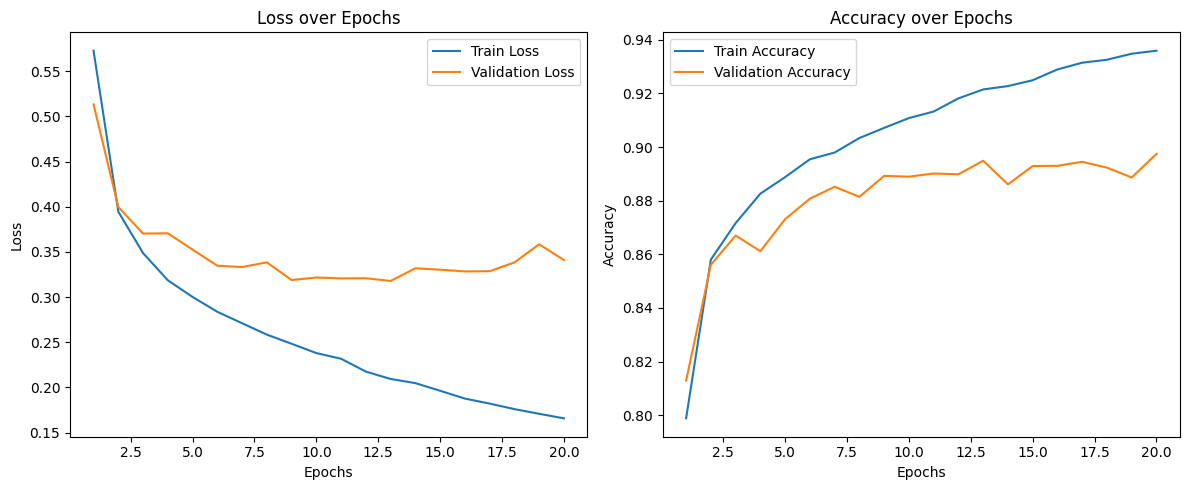

In [29]:
loss_accuracy_plots(train_losses_1, train_accuracy_1, val_losses_1, val_accuracy_1)

## Exercise - Now You Do It!

Make a classifier for the digits. 

I really recommend that you try to do this from scratch, without relying on the solution or other examples as much as possible. Look up documentation as needed, but try to generate all the code on your own. This isn't just for needless suffering, the practice of making it work and figuring out errors/issues (that you will encounter) is good practice. That includes the training loop, try to make one by hand and you'll likely hit some issues as you make things work, that's good. 

In [30]:
minst_digits_train = MNIST(root="data",train=True,download=True,
                        transform=transforms.ToTensor())
minst_digits_test = MNIST(root="data",train=False,download=True,
                        transform=transforms.ToTensor())

digit_train_loader = DataLoader(minst_digits_train, batch_size=BATCH_SIZE, shuffle=True)
digit_test_loader = DataLoader(minst_digits_test, batch_size=BATCH_SIZE, shuffle=False)

In [31]:
class DigitModel(nn.Module):

    def __init__(self, dimensions=28*28, output_classes=10, hidden_units=[256, 128]):
        super(DigitModel, self).__init__()
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(in_features=dimensions, out_features=hidden_units[0])
        self.activation_1 = nn.ReLU()
        self.hidden_layer_2 = nn.Linear(in_features=hidden_units[0], out_features=hidden_units[1])
        self.activation_3 = nn.ReLU()
        self.output_layer = nn.Linear(in_features=hidden_units[1], out_features=output_classes)
    def forward(self, x):
        x = self.flatten(x)
        x = self.input_layer(x)
        x = self.activation_1(x)
        x = self.hidden_layer_2(x)
        x = self.activation_3(x)
        x = self.output_layer(x)
        return x
    
digit_model = DigitModel(dimensions=28*28, output_classes=10, hidden_units=[256, 128])
optimizer_digit = torch.optim.Adam(params=digit_model.parameters(), lr=0.001)
loss_criterion_digit = nn.CrossEntropyLoss()

In [32]:
def digitTrainer(model, train_loader, test_loader, optimizer, loss_criterion, epochs, device):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = processEpoch(model, train_loader, optimizer, loss_criterion, device, doTraining=True)
        val_loss, val_accuracy = processEpoch(model, test_loader, optimizer, loss_criterion, device, doTraining=False)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch: {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    return train_losses, train_accuracies, val_losses, val_accuracies

train_losses_digit, train_accuracies_digit, val_losses_digit, val_accuracies_digit = digitTrainer(
    model=digit_model,
    train_loader=digit_train_loader,
    test_loader=digit_test_loader,
    optimizer=optimizer_digit,
    loss_criterion=loss_criterion_digit,
    epochs=EPOCHS,
    device=device
)

Epoch: 1/20 | Train Loss: 0.3450, Train Accuracy: 0.9051 | Val Loss: 0.1559, Val Accuracy: 0.9552
Epoch: 2/20 | Train Loss: 0.1335, Train Accuracy: 0.9607 | Val Loss: 0.1082, Val Accuracy: 0.9670
Epoch: 3/20 | Train Loss: 0.0888, Train Accuracy: 0.9733 | Val Loss: 0.0938, Val Accuracy: 0.9708
Epoch: 4/20 | Train Loss: 0.0622, Train Accuracy: 0.9807 | Val Loss: 0.0795, Val Accuracy: 0.9742
Epoch: 5/20 | Train Loss: 0.0494, Train Accuracy: 0.9845 | Val Loss: 0.0834, Val Accuracy: 0.9749
Epoch: 6/20 | Train Loss: 0.0372, Train Accuracy: 0.9886 | Val Loss: 0.0718, Val Accuracy: 0.9777
Epoch: 7/20 | Train Loss: 0.0276, Train Accuracy: 0.9916 | Val Loss: 0.0836, Val Accuracy: 0.9753
Epoch: 8/20 | Train Loss: 0.0227, Train Accuracy: 0.9929 | Val Loss: 0.0725, Val Accuracy: 0.9796
Epoch: 9/20 | Train Loss: 0.0197, Train Accuracy: 0.9934 | Val Loss: 0.0761, Val Accuracy: 0.9798
Epoch: 10/20 | Train Loss: 0.0152, Train Accuracy: 0.9950 | Val Loss: 0.0913, Val Accuracy: 0.9771
Epoch: 11/20 | Trai

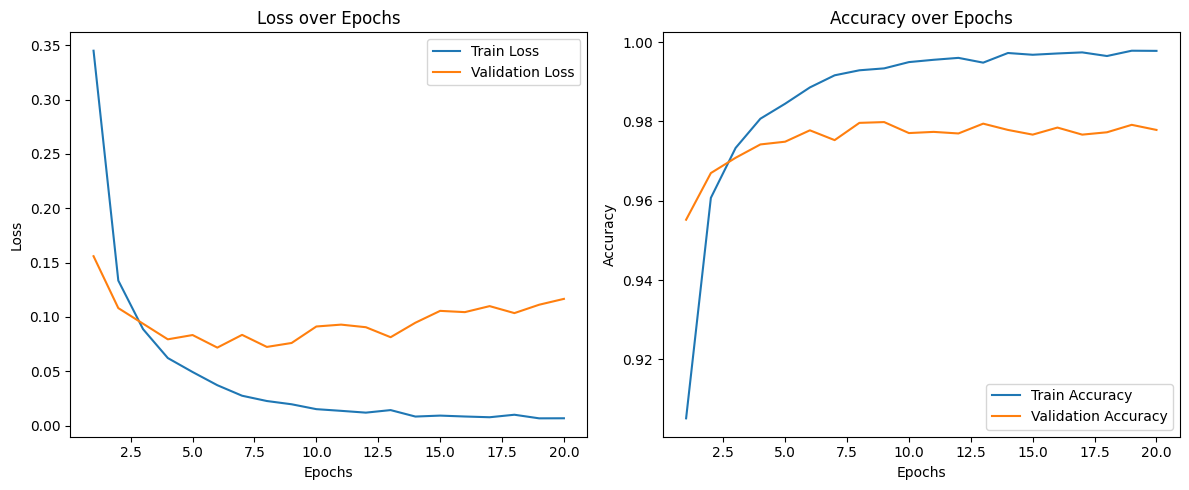

In [33]:
loss_accuracy_plots(train_losses_digit, train_accuracies_digit, val_losses_digit, val_accuracies_digit)